In [1]:
import os

def plot_grid(base_path, n_samples, title='gumbel',iou_type='soft_iou', filename=None, save=False):
    fig, axes = plt.subplots(n_samples // 3, 3, figsize=(15, n_samples // 3 * 4))
    axes = axes.ravel()

    fig.suptitle(f'{title}', fontsize=16, y=0.99)
    
    idx = -1
    n_plotted = 0
    while n_plotted != n_samples:
        idx += 1
        file_name = f'{base_path}/results_sample={idx}.csv'
        
        if not os.path.exists(file_name):
            continue

        df = pd.read_csv(file_name)
        df = df[df['iteration'] != 0]

        if len(df) < 10:
            continue

        correlation = corr(df, iou_type, 'iou')
        
        plt.sca(axes[n_plotted])
        for y, label in zip([df['iou'], df[iou_type]], ['IOU', iou_type]):
            plt.plot(df['iteration'], y, label=label, alpha=0.6)
        
        plt.xlabel('Iteration')
        plt.ylabel('IOU Score')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.title(f'Sample {idx}, Corr: {correlation:.3f}')
        n_plotted += 1
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    if save:
        if filename is None:
            plt.savefig(f'./{title}-{iou_type}.png')
        else:
            plt.savefig(f'./{filename}.png')
    plt.show()

## Hard / Soft

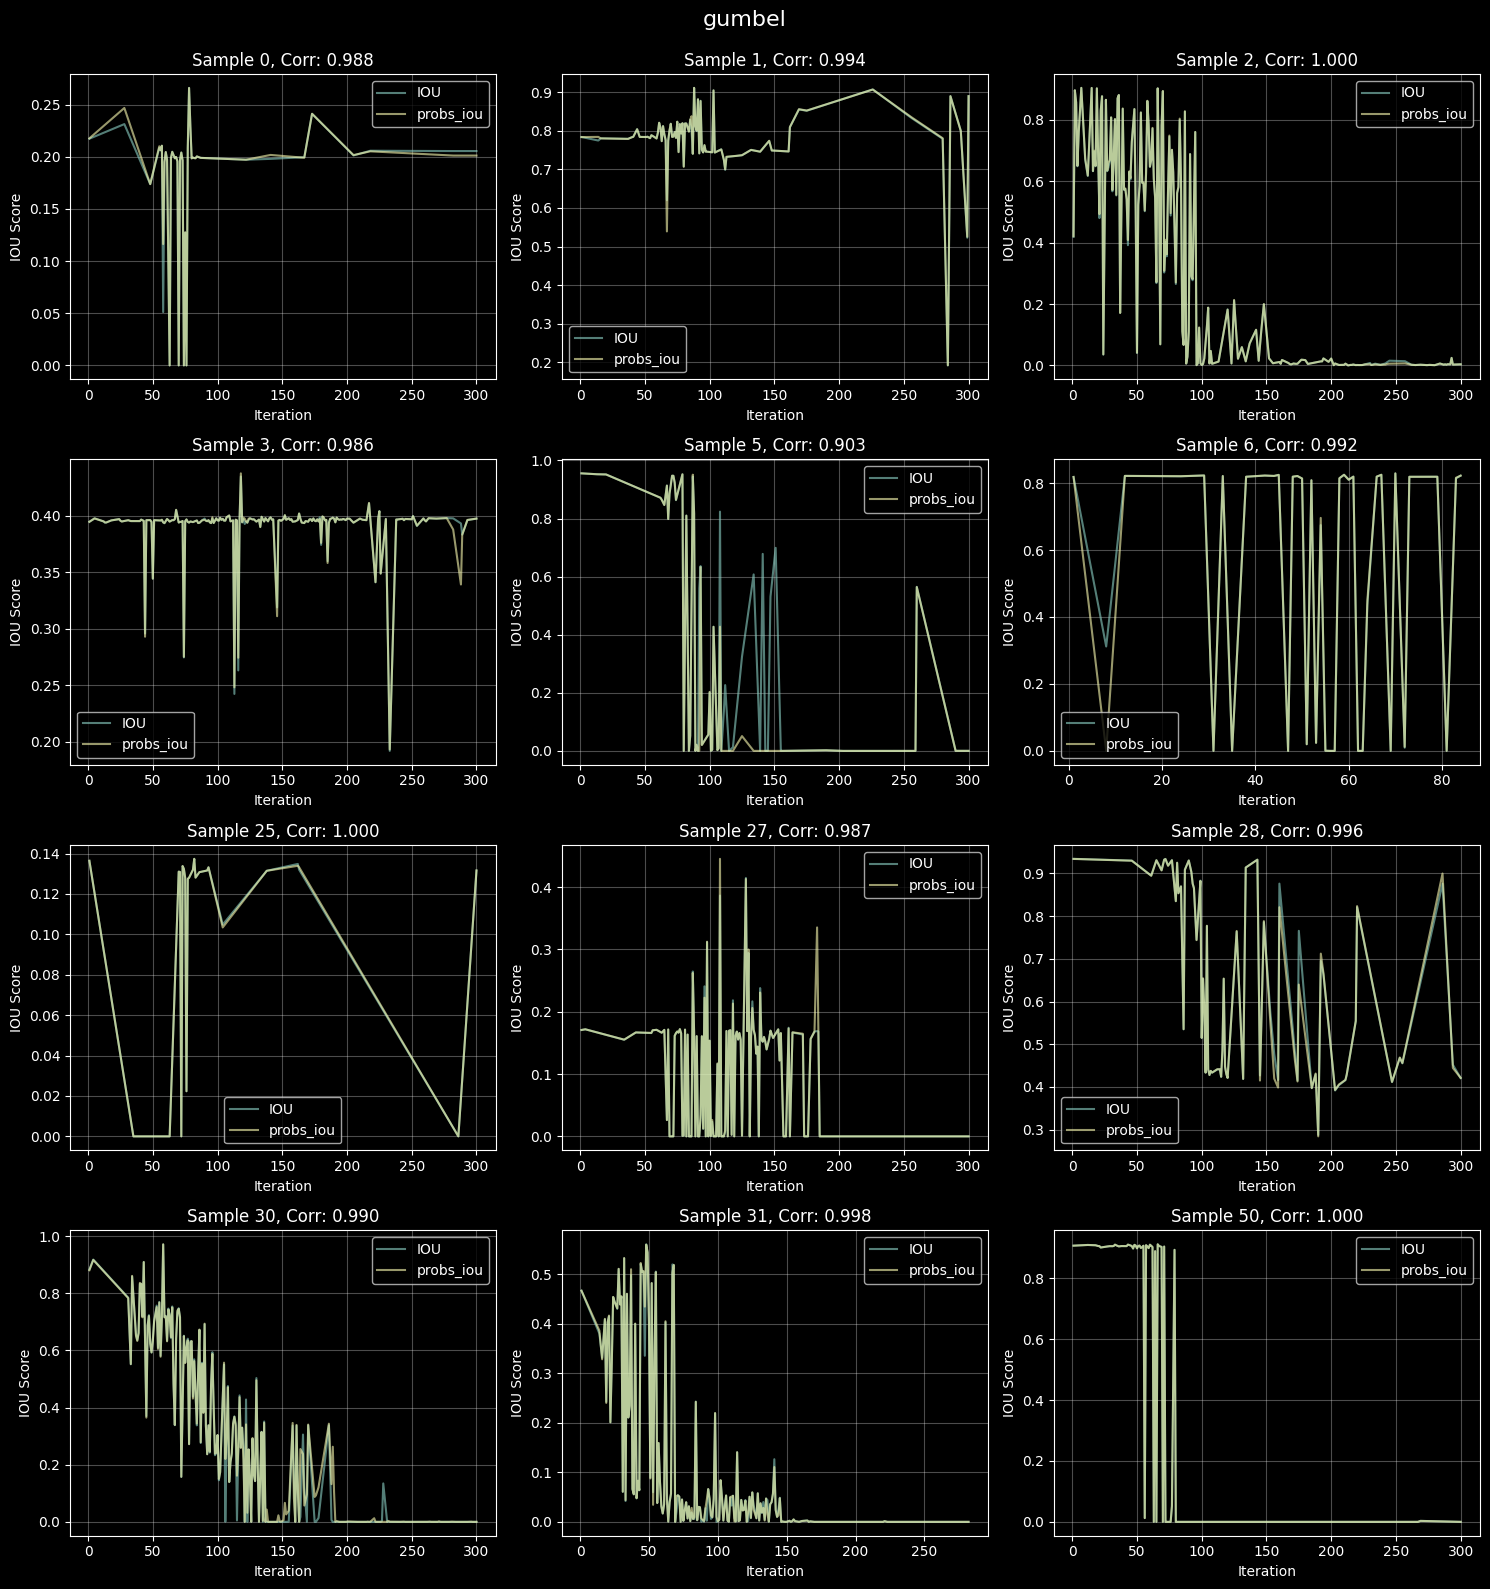

In [5]:
base_path = '../../experiments/soft-hard-input/gumbel'
plot_grid(base_path, 12, iou_type='probs_iou', save=True)

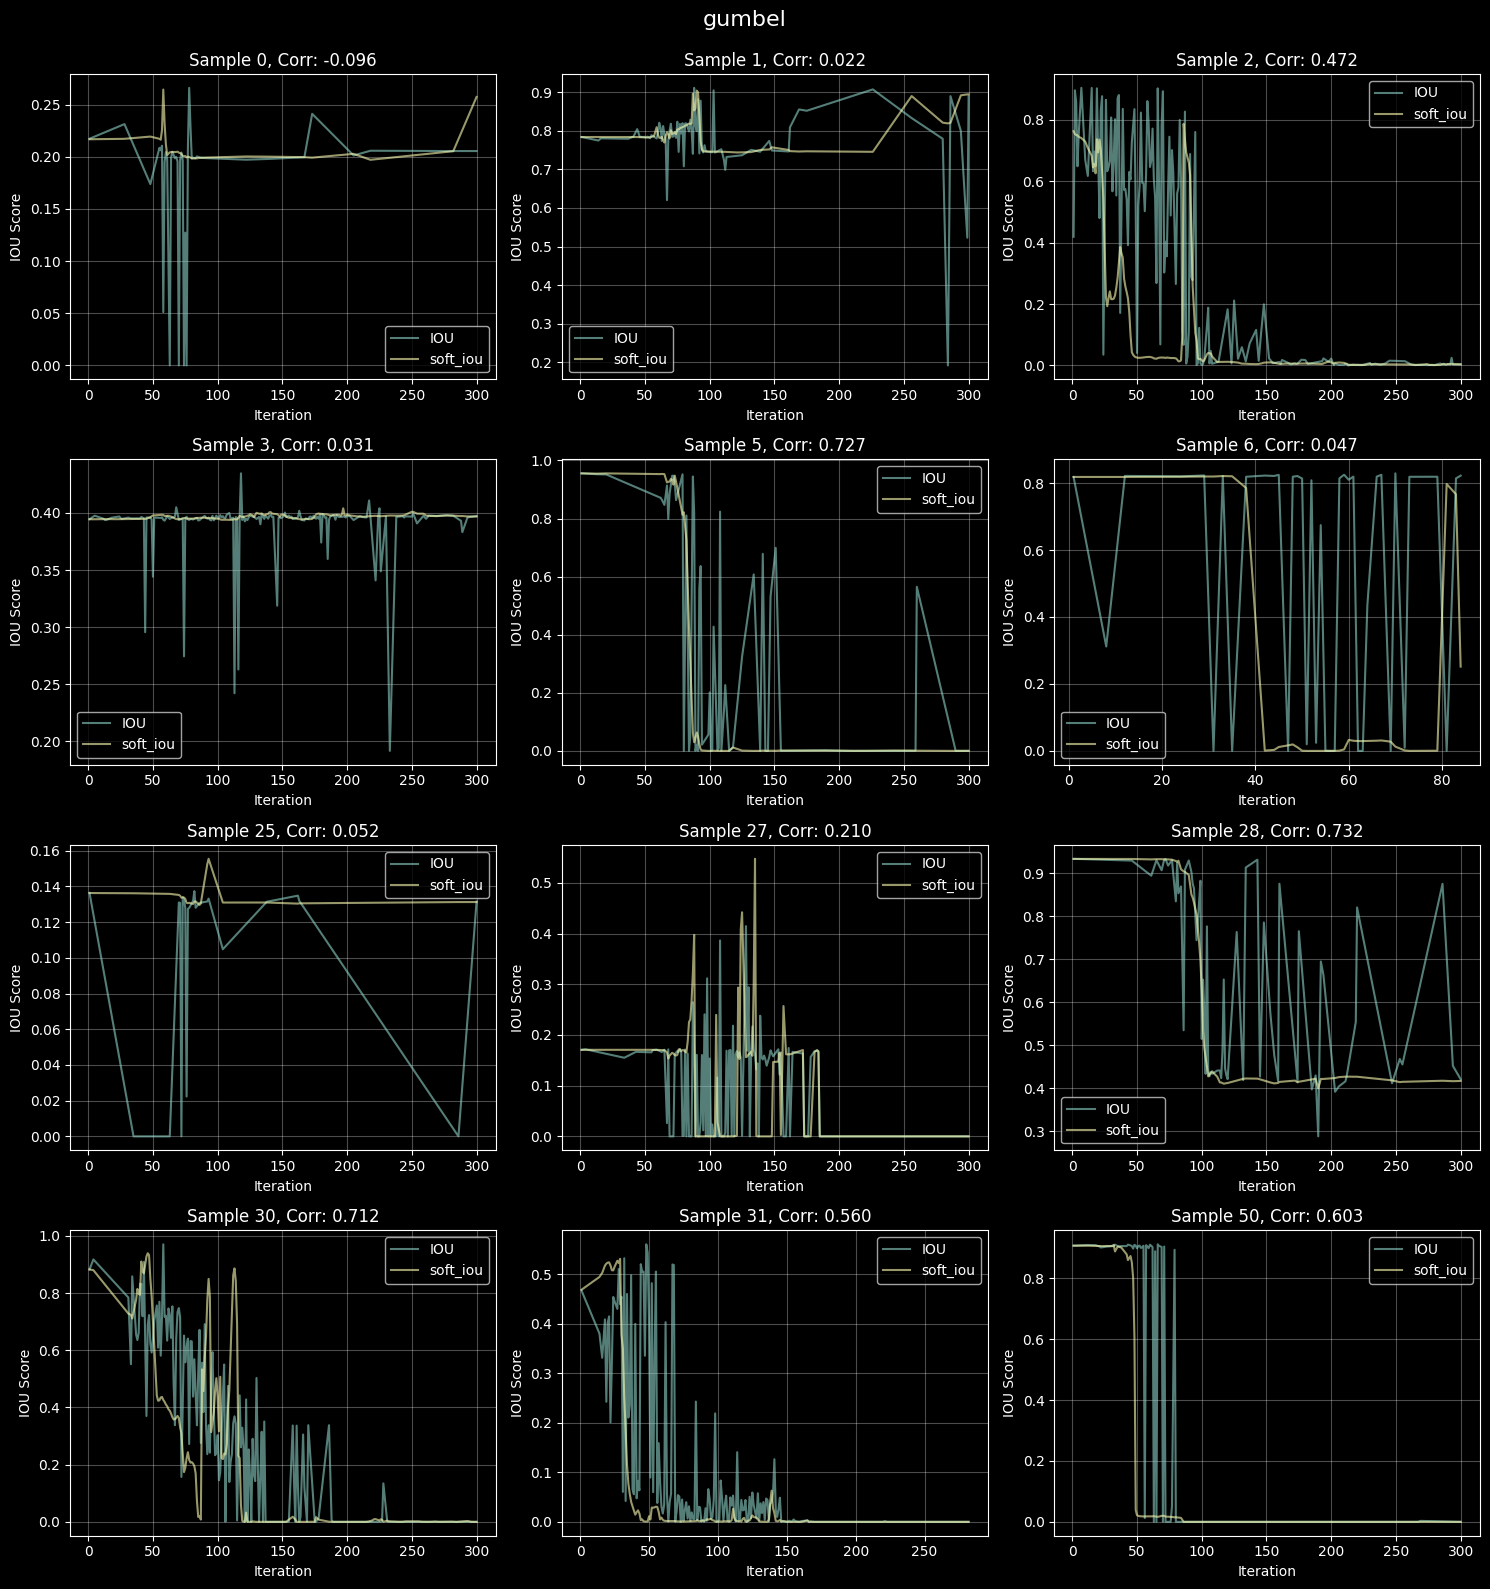

In [6]:
base_path = '../../experiments/soft-hard-input/gumbel'
plot_grid(base_path, 12, iou_type='soft_iou', save=True)

In [ ]:
base_path = '../../experiments/03-10-2025_14-38-48-560983'
plot_grid(base_path, 12, iou_type='soft_iou', title='sonar', save=True)

## Negative adv_loss

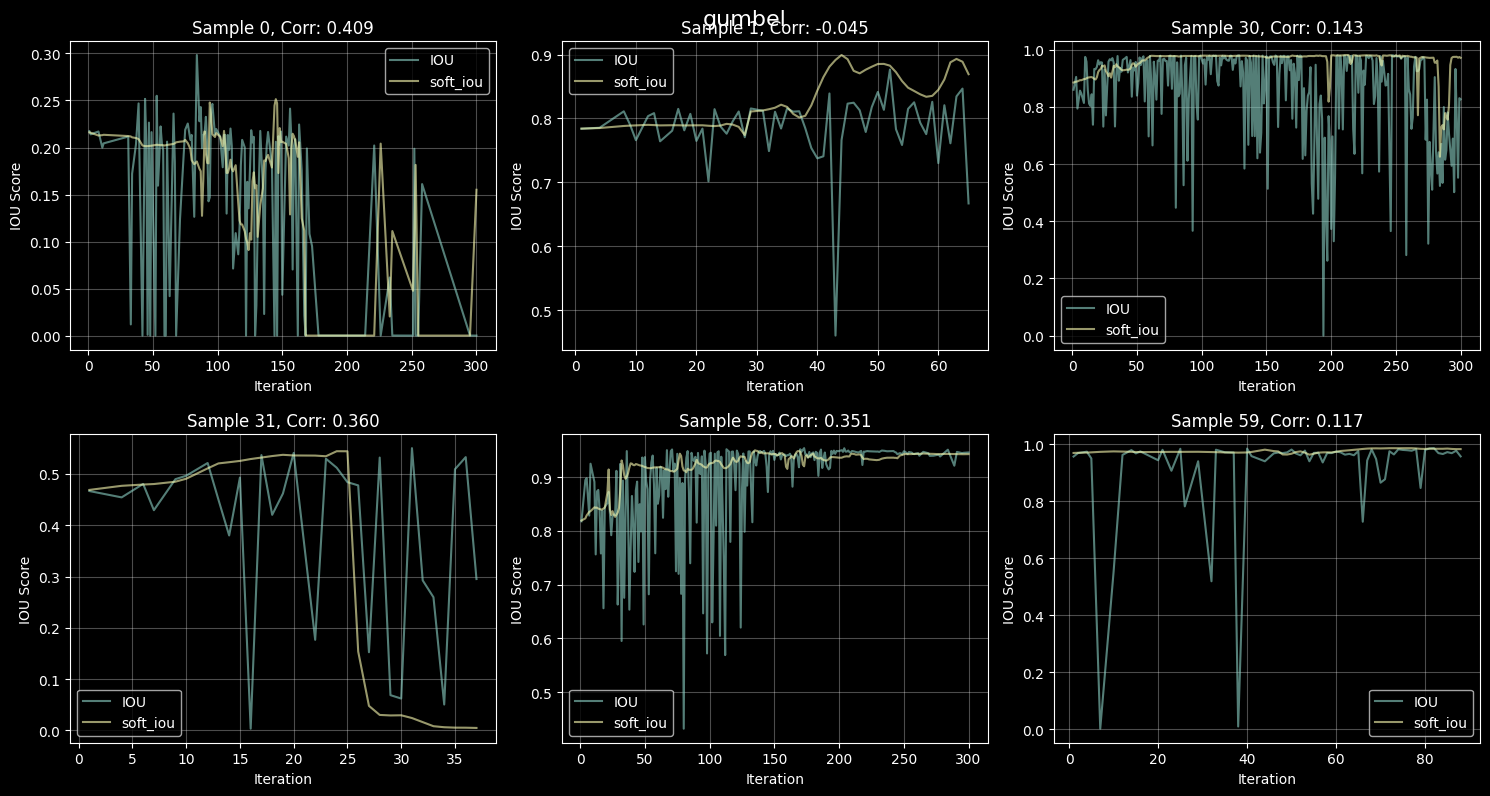

In [74]:
base_path = '../../experiments/negative-adv-loss/gumbel-only-adv'
plot_grid(base_path, 6, iou_type='soft_iou', save=True)

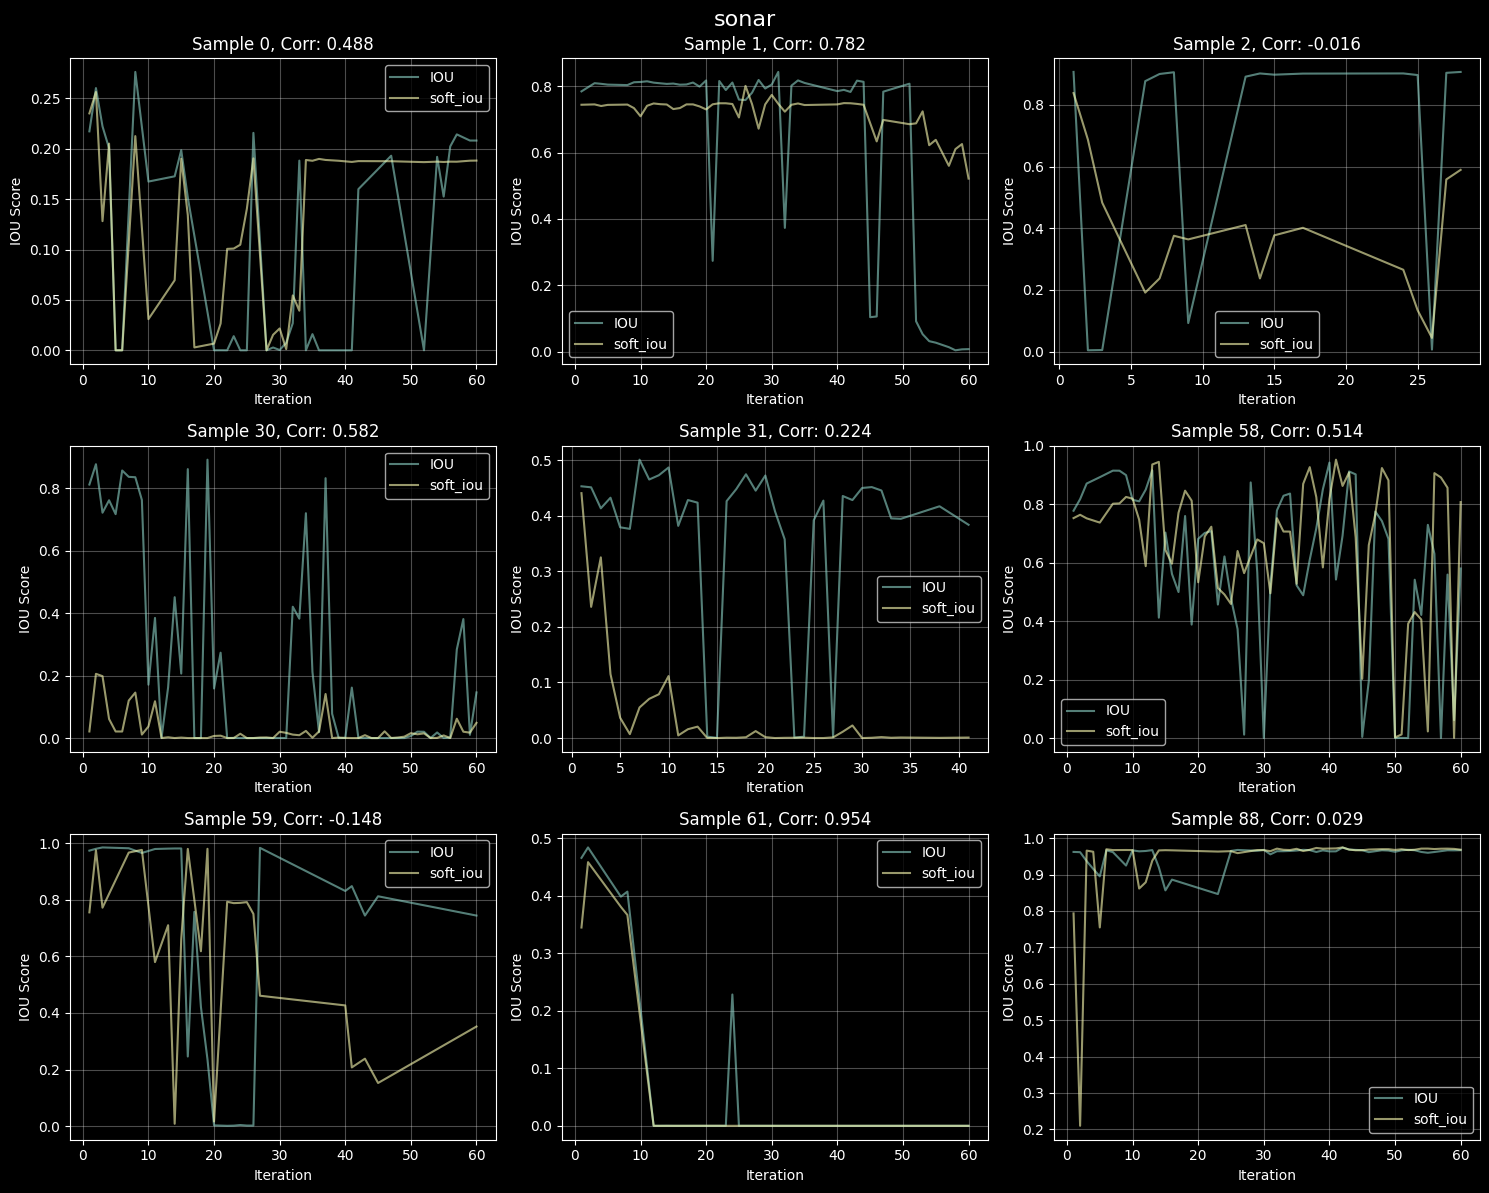

In [7]:
base_path = '../../experiments/negative-adv-loss/sonar-only-adv'
plot_grid(base_path, 9, iou_type='soft_iou', save=True, title='sonar')

## Meta-tokenization

### First try

#### Texts

In [1]:
import os
import json

json_dir = "/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break/dataset/reason_seg/ReasonSeg/test"

texts = []

for filename in os.listdir(json_dir):
    if filename.endswith(".json"):
        file_path = os.path.join(json_dir, filename)
        with open(file_path, 'r') as f:
            data = json.load(f)
            if "text" in data:
                texts.extend(data["text"])

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")

Extracted texts:
Total number of texts: 3408


#### Utilities (tokenizers)

In [1]:
from transformers import AutoTokenizer

lisa_tokenizer = AutoTokenizer.from_pretrained(
    "xinlai/LISA-13B-llama2-v1",
    use_fast=False,
    add_eos_token=True
)
lisa_tokenizer.pad_token = lisa_tokenizer.unk_token


import torch

from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(
    encoder="text_sonar_basic_encoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)
        
sonar_v2t = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)

/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
def lisa_tokenize(text):
    return lisa_tokenizer.encode(text, add_special_tokens=False)

def lisa_decode(tokens):
    return lisa_tokenizer.decode(tokens, skip_special_tokens=True)

def sonar_tokenize(text):
    return sonar_t2v.tokenizer.create_encoder(lang="eng_Latn")(text)[1:-1].tolist()

def sonar_decode(tokens):
    return str(sonar_t2v.tokenizer.create_decoder()(torch.tensor(tokens)))


text = "Hello, world!"
print('sonar: \t', sonar_tokenize(text))
print('lisa: \t', lisa_tokenize(text))

sonar: 	 [94124, 248079, 15697, 248203]
lisa: 	 [15043, 29892, 3186, 29991]


#### Optimization

In [68]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.nn.functional import softmax


class ToySegmentationModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, output_size=(32, 32)):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_size[0] * output_size[1])
        self.output_size = output_size
        
    def forward(self, x):
        batch_size, seq_len, vocab_size = x.shape
        
        embedded = x @ self.embedding.weight.data
        lstm_out, _ = self.lstm(embedded)  # [batch_size, seq_len, hidden_dim]
        last_output = lstm_out[:, -1, :]  # [batch_size, hidden_dim]
        
        x = torch.relu(self.fc1(last_output))
        x = self.fc2(x)
        mask = torch.sigmoid(x).view(batch_size, *self.output_size)
        return mask
    

def dice_loss(pred, target, smooth=1.0):
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return 1 - ((2. * intersection + smooth) / 
                (pred_flat.sum() + target_flat.sum() + smooth))


text = 'colored region'
tokens = lisa_tokenize(text)
print(f"Text: '{text}' -> Tokens: {tokens}")


target_size = (32, 32)
target_mask = torch.zeros(target_size)

center_x, center_y = target_size[0] // 2, target_size[1] // 2
radius = min(target_size) // 4
for i in range(target_size[0]):
    for j in range(target_size[1]):
        if ((i - center_x) ** 2 + (j - center_y) ** 2) <= radius ** 2:
            target_mask[i, j] = 1.0


vocab_size = lisa_tokenizer.vocab_size
model = ToySegmentationModel(vocab_size, output_size=target_size)

seq_len = len(tokens)
one_hot = torch.zeros(1, seq_len, vocab_size)
for i, token_id in enumerate(tokens):
    one_hot[0, i, token_id] = 1.0

Text: 'colored region' -> Tokens: [28684, 5120]


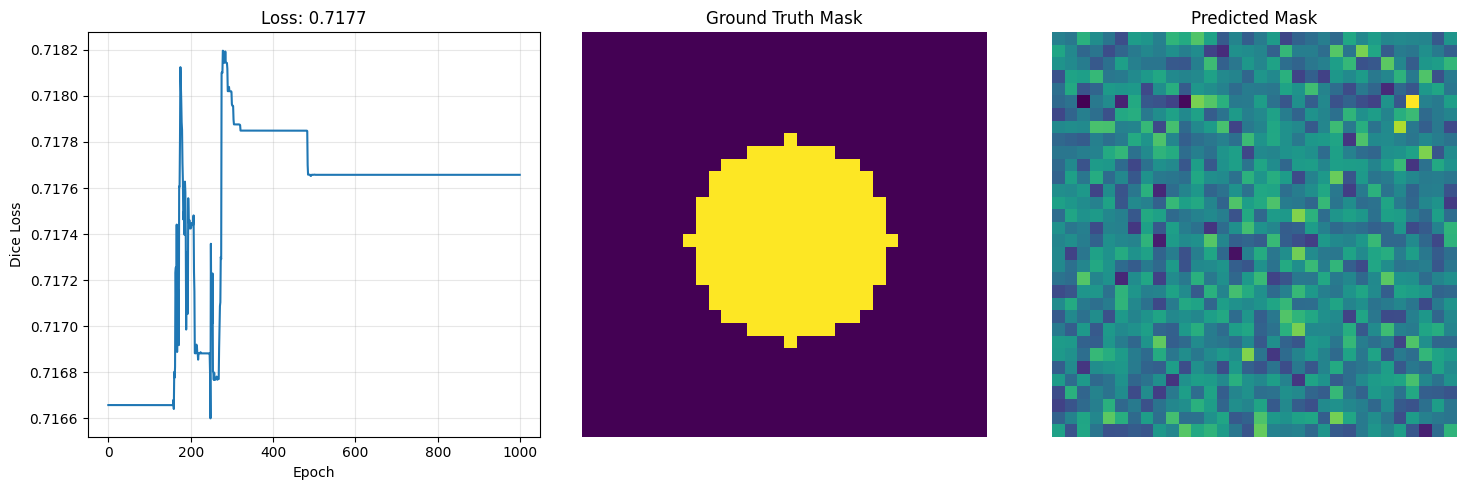

100%|██████████| 1000/1000 [01:34<00:00, 10.57it/s]

Epoch [1000/1000], Loss: 0.7177


In [71]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

one_hot = one_hot.requires_grad_(True)
optimizer = optim.Adam([one_hot], lr=0.01)

num_epochs = 1000
losses = []

for epoch in tqdm(range(num_epochs)):
    pred_mask = model(one_hot)
    
    loss = dice_loss(pred_mask[0], target_mask)
    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        # Clear the previous output and plot
        clear_output(wait=True)
        
        # Create a new figure
        plt.figure(figsize=(15, 5))
        
        # Plot loss history
        plt.subplot(1, 3, 1)
        plt.plot(losses)
        plt.title(f'Loss: {loss.item():.4f}')
        plt.xlabel('Epoch')
        plt.ylabel('Dice Loss')
        plt.grid(True, alpha=0.3)
        
        # Plot ground truth mask
        plt.subplot(1, 3, 2)
        plt.imshow(target_mask.detach().numpy(), cmap='viridis')
        plt.title('Ground Truth Mask')
        plt.axis('off')
        
        # Plot predicted mask
        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask[0].detach().numpy(), cmap='viridis')
        plt.title('Predicted Mask')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

### Graphs

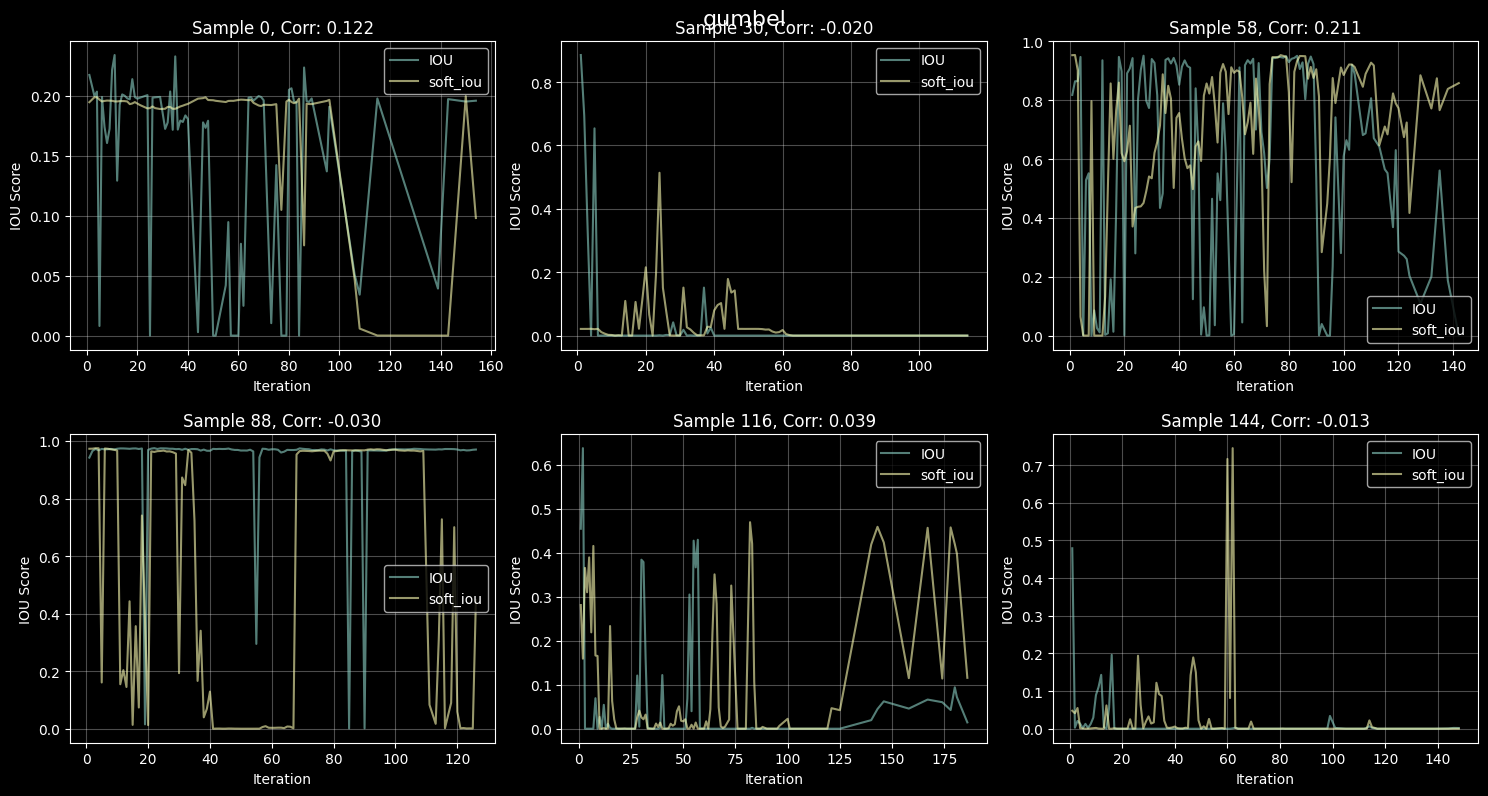

In [21]:
base_path = '../../experiments/03-12-2025_10-32-14-452444'
plot_grid(base_path, 6, iou_type='soft_iou', save=True)

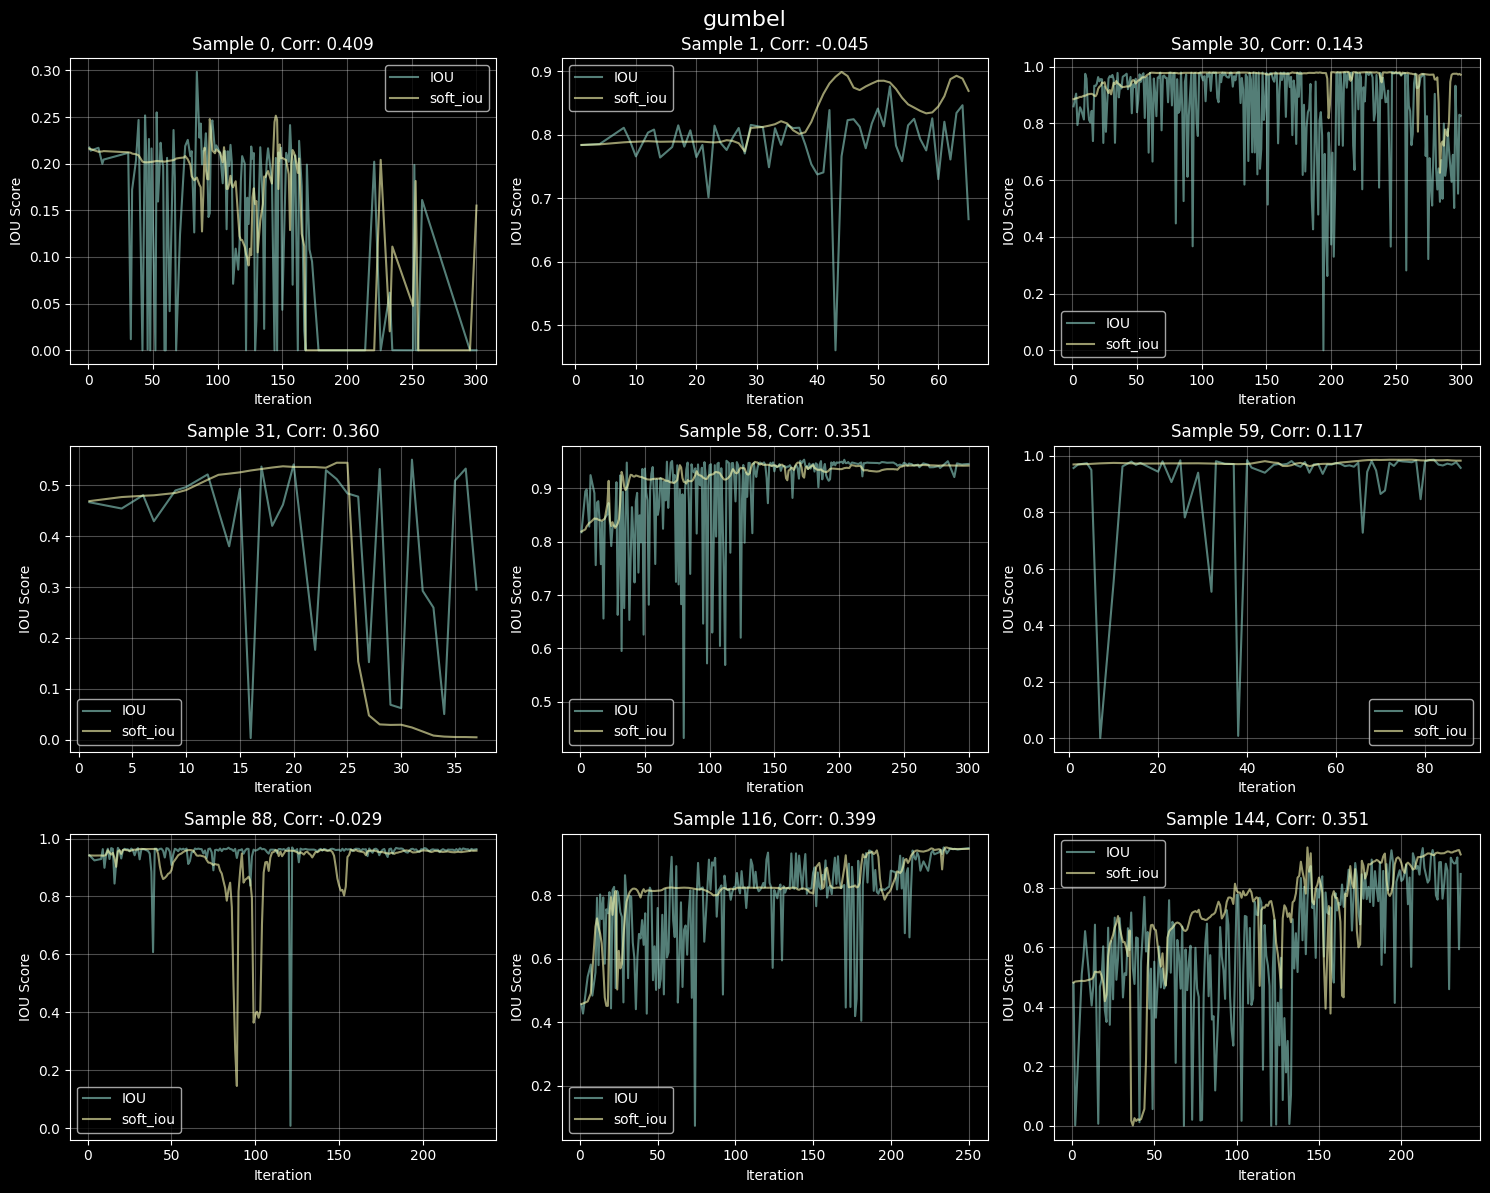

In [18]:
base_path = '../../experiments/meta-gumbel/just-meta'
plot_grid(base_path, 9, iou_type='soft_iou', save=True)

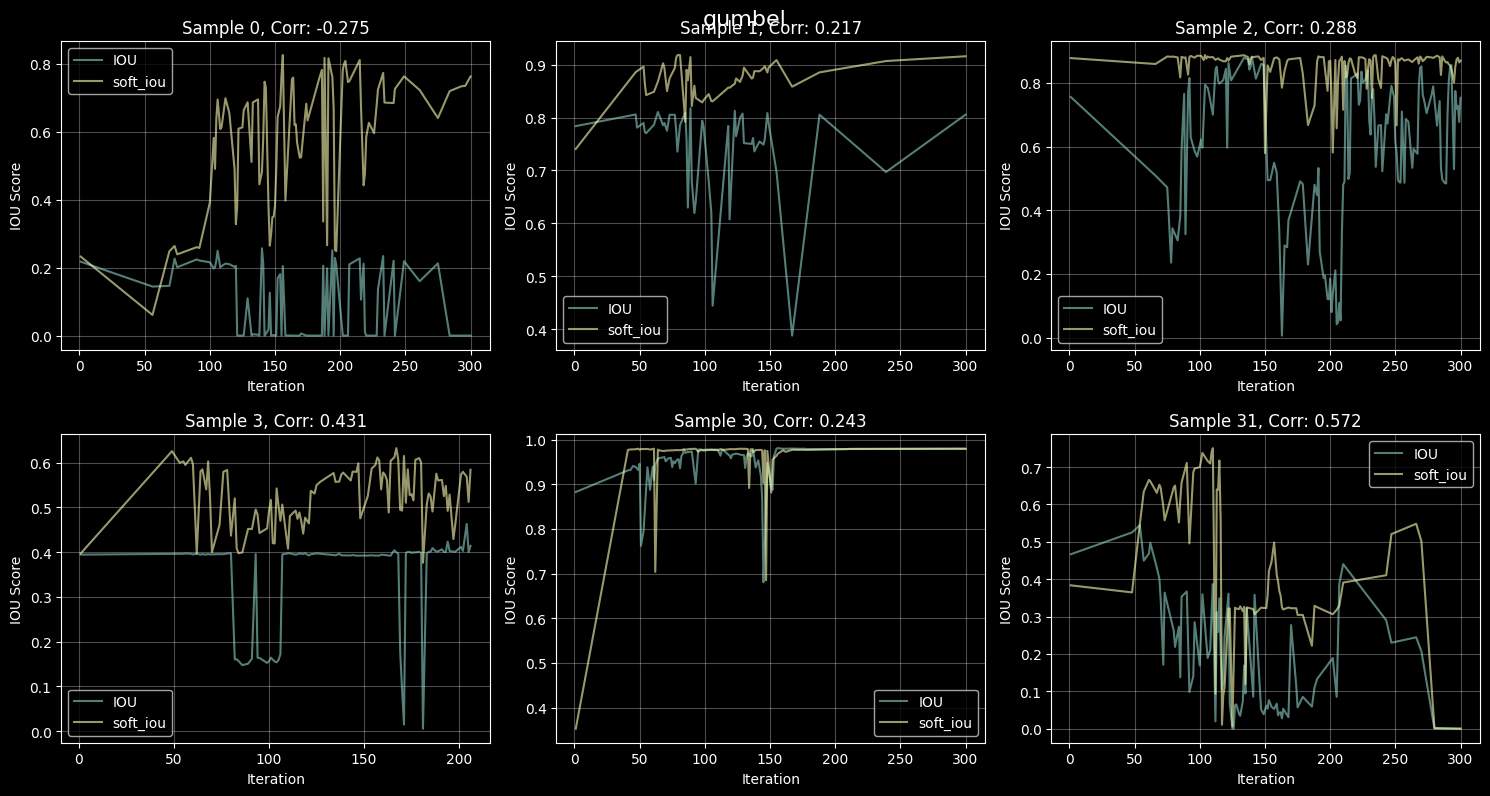

In [34]:
base_path = '../../experiments/03-11-2025_18-33-08-421899'
plot_grid(base_path, 6, iou_type='soft_iou', save=True)

### Meta-tokenization statistics

#### texts

In [1]:
import os
import json

json_dir = "/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break/dataset/reason_seg/ReasonSeg/test"

texts = []

for filename in os.listdir(json_dir):
    if filename.endswith(".json"):
        file_path = os.path.join(json_dir, filename)
        with open(file_path, 'r') as f:
            data = json.load(f)
            if "text" in data:
                texts.extend(data["text"])

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")

Extracted texts:
Total number of texts: 3408


#### sonar tokens

In [2]:
import torch

from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(
    encoder="text_sonar_basic_encoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)
        
sonar_v2t = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder", 
    tokenizer="text_sonar_basic_encoder",
    device='cuda'
)

def get_sonar_embedding(text):
    with torch.no_grad():
        embedding = sonar_t2v.predict([text], source_lang="eng_Latn")
    return embedding

In [3]:
def sonar_tokenize(text):
    return sonar_t2v.tokenizer.create_encoder(lang="eng_Latn")(text)[1:-1].tolist()

def sonar_decode(tokens):
    return str(sonar_t2v.tokenizer.create_decoder()(torch.tensor(tokens)))

text = "Hello, world!"
sonar_tokenize(text)

[94124, 248079, 15697, 248203]

#### lisa tokens

In [4]:
from transformers import AutoTokenizer

lisa_tokenizer = AutoTokenizer.from_pretrained(
    "xinlai/LISA-13B-llama2-v1",
    use_fast=False,
    add_eos_token=True
)
lisa_tokenizer.pad_token = lisa_tokenizer.unk_token

/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [5]:
def lisa_tokenize(text):
    return lisa_tokenizer.encode(text, add_special_tokens=False)

def lisa_decode(tokens):
    return lisa_tokenizer.decode(tokens, skip_special_tokens=True)

text = "Hello, world!"
lisa_tokenize(text)

[15043, 29892, 3186, 29991]

#### comparison

In [8]:
lisa_tokenizer.get_vocab()

{'<unk>': 0,
 '<s>': 1,
 '</s>': 2,
 '<0x00>': 3,
 '<0x01>': 4,
 '<0x02>': 5,
 '<0x03>': 6,
 '<0x04>': 7,
 '<0x05>': 8,
 '<0x06>': 9,
 '<0x07>': 10,
 '<0x08>': 11,
 '<0x09>': 12,
 '<0x0A>': 13,
 '<0x0B>': 14,
 '<0x0C>': 15,
 '<0x0D>': 16,
 '<0x0E>': 17,
 '<0x0F>': 18,
 '<0x10>': 19,
 '<0x11>': 20,
 '<0x12>': 21,
 '<0x13>': 22,
 '<0x14>': 23,
 '<0x15>': 24,
 '<0x16>': 25,
 '<0x17>': 26,
 '<0x18>': 27,
 '<0x19>': 28,
 '<0x1A>': 29,
 '<0x1B>': 30,
 '<0x1C>': 31,
 '<0x1D>': 32,
 '<0x1E>': 33,
 '<0x1F>': 34,
 '<0x20>': 35,
 '<0x21>': 36,
 '<0x22>': 37,
 '<0x23>': 38,
 '<0x24>': 39,
 '<0x25>': 40,
 '<0x26>': 41,
 '<0x27>': 42,
 '<0x28>': 43,
 '<0x29>': 44,
 '<0x2A>': 45,
 '<0x2B>': 46,
 '<0x2C>': 47,
 '<0x2D>': 48,
 '<0x2E>': 49,
 '<0x2F>': 50,
 '<0x30>': 51,
 '<0x31>': 52,
 '<0x32>': 53,
 '<0x33>': 54,
 '<0x34>': 55,
 '<0x35>': 56,
 '<0x36>': 57,
 '<0x37>': 58,
 '<0x38>': 59,
 '<0x39>': 60,
 '<0x3A>': 61,
 '<0x3B>': 62,
 '<0x3C>': 63,
 '<0x3D>': 64,
 '<0x3E>': 65,
 '<0x3F>': 66,
 '<0x40>': 

In [31]:
lisa_tokenize('▁?'), lisa_tokenize('?'), lisa_tokenize('~?'), lisa_tokenize(' ?')

([29871, 1577], [1577], [3695, 29973], [29871, 1577])

In [33]:
lisa_decode([29973]), lisa_decode([1577])

('?', '?')

In [17]:
sonar_tokenize('▁function'), sonar_tokenize('function'), sonar_tokenize('~function')

([75007], [75007], [9428, 247551])

In [20]:
sonar_decode([75007]), sonar_decode([247551])

('function', 'function')

In [14]:
sonar_tokenize('text')

[35883]

In [10]:
sonar_decode([35883])

'text'

In [11]:
sonar_tokenize('~text')

[9428, 54525]

In [1]:
sonar_decode([54525])

NameError: name 'sonar_decode' is not defined

##### vec + pseudo

In [91]:
sonar_probs = torch.load('../../sonar_probs.pt')
sonar_probs.shape

torch.Size([20, 256206])

In [92]:
import numpy as np

def get_tokens(probs):
    sonar_tokens = probs.argmax(dim=-1)
    text = sonar_decode(sonar_tokens)
    lisa_tokens = lisa_tokenizer.encode(text, add_special_tokens=False)
    return sonar_tokens, lisa_tokens

def create_one_hot_matrix(tokens, vocab_size):
    matrix = np.zeros((len(tokens), vocab_size))
    for i, token in enumerate(tokens):
        matrix[i, token] = 1
    return matrix

sonar_tokens, lisa_tokens = get_tokens(sonar_probs)

/tmp/ipykernel_1471628/3132252357.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return str(sonar_t2v.tokenizer.create_decoder()(torch.tensor(tokens)))


In [98]:
len(sonar_tokens), len(lisa_tokens)

(20, 20)

In [ ]:
sonar_one_hot = create_one_hot_matrix(lisa_tokens, lisa_tokenizer.vocab_size)

In [93]:
lisa_one_hot = create_one_hot_matrix(lisa_tokens, lisa_tokenizer.vocab_size)

In [94]:
lisa_one_hot.shape

(20, 32000)

In [95]:
print(lisa_decode(lisa_one_hot.argmax(-1)))
print(sonar_decode(sonar_tokens))

What object in the picture is most suitable for plating food on and enjoying a meal?
What object in the picture is most suitable for plating food on and enjoying a meal?


/tmp/ipykernel_1471628/3132252357.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return str(sonar_t2v.tokenizer.create_decoder()(torch.tensor(tokens)))


In [74]:
A = sonar_probs.reshape(-1)
B = lisa_one_hot.reshape(-1)
A.shape, B.shape

((5124120,), (640000,))

In [81]:
import numpy as np
from scipy.sparse import csr_matrix

def create_transition_matrix(A, B, batch_size=1000, threshold=1e-5):
    n_a = A.shape[0]
    n_b = B.shape[0]
    
    rows = []
    cols = []
    data = []
    
    for start in range(0, n_b, batch_size):
        end = min(start + batch_size, n_b)
        
        B_batch = B[start:end]
        
        for i in range(end - start):
            b_val = B_batch[i]
            if abs(b_val) > threshold:
                diff = np.abs(A - b_val)
                closest_idx = np.argmin(diff)
                
                rows.append(start + i)
                cols.append(closest_idx)
                data.append(1.0)
    
    T = csr_matrix((data, (rows, cols)), shape=(n_b, n_a))
    
    row_sums = np.array(T.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1
    T = T.multiply(1 / row_sums[:, np.newaxis])
    return T

In [82]:
# Create transition matrix
T = create_transition_matrix(A, B)
# or
# T = create_transition_matrix_optimized(A, B)

# Make prediction
pred = T @ A

# Evaluate
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(B, pred)
print(f"Mean Squared Error: {mse:.6f}")

# Print matrix statistics
print(f"Transition matrix shape: {T.shape}")
print(f"Transition matrix sparsity: {1 - T.nnz / (T.shape[0] * T.shape[1]):.6f}")

Mean Squared Error: 0.000000
Transition matrix shape: (640000, 5124120)
Transition matrix sparsity: 1.000000


In [ ]:
def scipy_sparse_to_torch_sparse(scipy_sparse):
    """Convert scipy sparse matrix to torch sparse tensor"""
    indices = torch.from_numpy(
        np.vstack((scipy_sparse.row, scipy_sparse.col))
    ).long()
    values = torch.from_numpy(scipy_sparse.data).float()
    shape = torch.Size(scipy_sparse.shape)
    return torch.sparse_coo_tensor(indices, values, shape)

In [85]:
# 3. Print as dense matrix (warning: might be very large!)
def print_partial_dense(T, max_rows=5, max_cols=5):
    """Print part of the matrix in dense format"""
    dense_part = T[:max_rows, :max_cols].toarray()
    print(f"\nFirst {max_rows}x{max_cols} elements as dense matrix:")
    print(dense_part)

print_partial_dense(T)


<COOrdinate sparse matrix of dtype 'float64'
	with 20 stored elements and shape (640000, 5124120)>

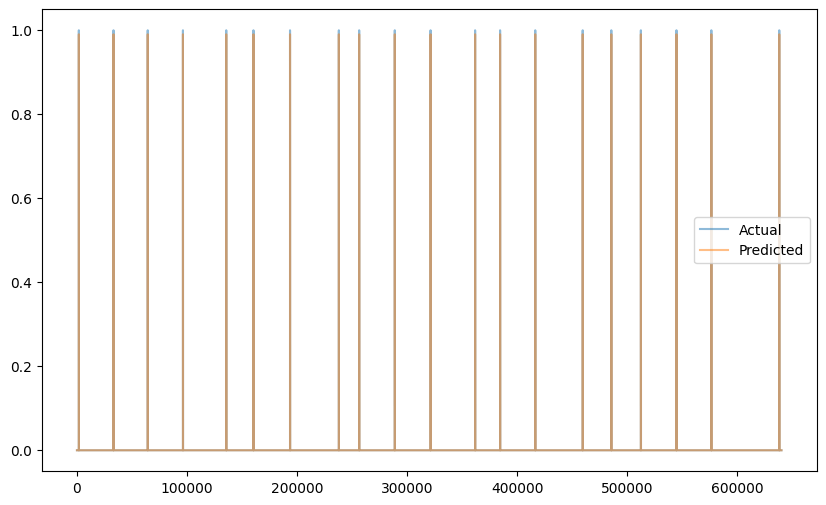

In [84]:
plt.figure(figsize=(10, 6))

# plt.plot(sonar_probs.reshape(-1), alpha=0.5, label='Actual sonar')
plt.plot(lisa_one_hot.reshape(-1), alpha=0.5, label='Actual')
plt.plot(pred, alpha=0.5, label='Predicted')
plt.legend()
plt.show()

In [47]:
sonar_probs = sonar_probs.cpu().detach().numpy()

In [48]:
T = find_transition_matrix(sonar_probs, lisa_one_hot)


In [88]:
def validate_transition_numpy(A, B, T):
    if hasattr(A, 'numpy'):
        A = A.numpy()
    if hasattr(B, 'numpy'):
        B = B.numpy()
    if hasattr(T, 'numpy'):
        T = T.numpy()
    
    # Check shapes
    assert T.shape == (B.reshape(-1).shape[0], A.reshape(-1).shape[0]), \
        f"Wrong shapes: T:{T.shape}, A:{A.shape}, B:{B.shape}"
    
    # Make prediction
    pred = T @ A.reshape(-1)
    
    # Calculate MSE error
    error = np.mean((pred - B.reshape(-1)) ** 2)
    print(f"Prediction error (MSE): {error:.6f}")
    
    # Additional helpful statistics
    print(f"Max absolute error: {np.max(np.abs(pred - B.reshape(-1))):.6f}")
    print(f"Mean absolute error: {np.mean(np.abs(pred - B.reshape(-1))):.6f}")
    
    return pred

pred = validate_transition_numpy(sonar_probs, lisa_one_hot, T)

Prediction error (MSE): 0.000000
Max absolute error: 0.009610
Mean absolute error: 0.000000


In [58]:
lisa_one_hot.reshape(-1).shape

(640000,)

In [59]:
pred.shape

(640000,)

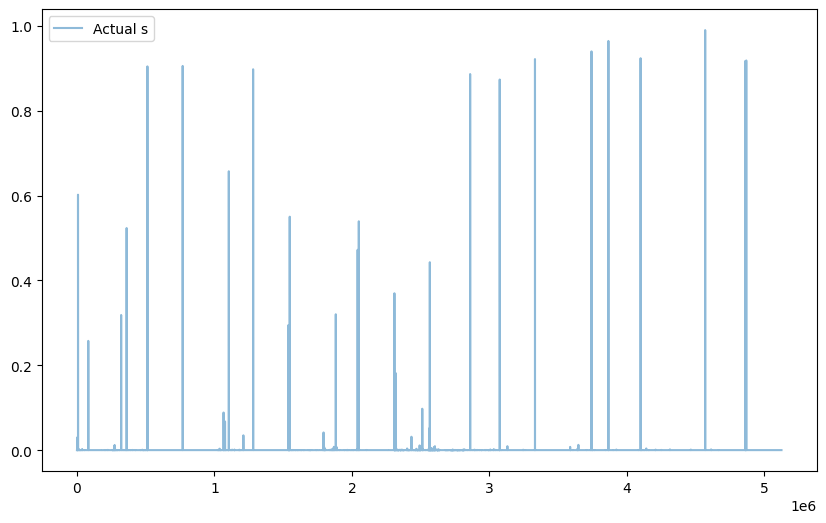

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(sonar_probs.reshape(-1), alpha=0.5, label='Actual sonar')
# plt.plot(lisa_one_hot.reshape(-1), alpha=0.5, label='Actual')
# plt.plot(pred, alpha=0.5, label='Predicted')
plt.legend()
plt.show()


In [65]:
# If you want to optimize the transition matrix:
def optimize_transition(A, B, T, learning_rate=0.01):
    optimizer = torch.optim.Adam([T], lr=learning_rate)
    
    for epoch in range(100):
        optimizer.zero_grad()
        
        # Forward pass
        pred = T @ A.reshape(-1)
        loss = torch.nn.functional.mse_loss(pred, B.reshape(-1))
        print('loss', loss.item())
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Project to valid transition matrix
        with torch.no_grad():
            T.data = torch.clamp(T.data, 0, 1)  # Non-negative
            T.data = T.data / T.data.sum(dim=1, keepdim=True)  # Row-sum = 1

In [66]:
A = torch.tensor(sonar_probs)
B = torch.tensor(lisa_one_hot)
T = torch.tensor(T)

TypeError: sparse array length is ambiguous; use getnnz() or shape[0]

In [40]:
optimize_transition(A, B, T)

TypeError: optimizer can only optimize Tensors, but one of the params is scipy.sparse._csr.csr_matrix

In [34]:
def validate_transition(A, B, T):
    assert T.shape == (B.reshape(-1).shape[0], A.reshape(-1).shape[0])
    
    pred = T @ A.reshape(-1)
    error = torch.nn.functional.mse_loss(torch.tensor(pred), B.reshape(-1))
    print(f"Prediction error: {error.item()}")

In [35]:
validate_transition(A, B, T)

Prediction error: 1.9971721448201127


In [ ]:
import torch
import numpy as np

# Assuming we have:
# A: shape [30000, 12] -> vectorized to [360000]
# B: shape [200000, 11] -> vectorized to [2200000]

def find_transition_matrix(A, B):
    # 1. First vectorize A and B if they're not already vectorized
    a_vec = A.reshape(-1)  # shape: [360000]
    b_vec = B.reshape(-1)  # shape: [2200000]
    
    # 2. Create transition matrix
    # Shape will be [2200000, 360000]
    # Warning: This might be too large for memory!
    
    # Instead of creating full matrix, we can:
    # a) Use sparse matrix
    from scipy.sparse import csr_matrix
    
    # b) Or find relationship between indices
    def map_indices(i, j, A_shape, B_shape):
        # Convert B index to A index
        b_row = i // B_shape[1]
        b_col = i % B_shape[1]
        
        a_row = (b_row * A_shape[0]) // B_shape[0]
        a_col = (b_col * A_shape[1]) // B_shape[1]
        
        return a_row * A_shape[1] + a_col

    # 3. Create sparse transition matrix
    rows = []
    cols = []
    data = []
    
    for i in range(b_vec.shape[0]):
        j = map_indices(i, i, A.shape, B.shape)
        if j < a_vec.shape[0]:
            rows.append(i)
            cols.append(j)
            data.append(1.0)
    
    T = csr_matrix((data, (rows, cols)), 
                   shape=(b_vec.shape[0], a_vec.shape[0]))
    
    return T

# Usage:
"""
# Create example data
A = torch.randn(30000, 12)
B = torch.randn(200000, 11)

# Find transition matrix
T = find_transition_matrix(A, B)

# To use the transition matrix:
b_pred = T @ A.reshape(-1)
b_pred = b_pred.reshape(200000, 11)
"""

##### mapping

▁ это пробел! сигнал, что кусок - начало слова

In [5]:
import numpy as np

import re
def is_english_only(text):
    return bool(re.match('^[a-zA-Z]+$', text))

def is_punctuation(text, punctuation = ['.', ',', '!', '?', ':', ';', '(', ')']):
    return text in punctuation

n_special_tokens = list(np.arange(0, 260)) + [32000, 32001, 32002, 32003]
matches = {}
n_lisa_tokens = 0

for lisa_subword, i in lisa_tokenizer.get_vocab().items():
    
    if i not in n_special_tokens and (is_english_only(lisa_subword.replace('▁', '')) or is_punctuation(lisa_subword.replace('▁', ''))):

        if lisa_subword.startswith('▁'):
            sonar_tokens = sonar_tokenize(lisa_subword)
        else:
            sonar_tokens = sonar_tokenize('~' + lisa_subword)[1:]

        if len(sonar_tokens) == 1:
            matches[lisa_subword] = {
                'sonar_token': sonar_tokens[0],
                'lisa_token' : i
            }
        n_lisa_tokens += 1
print(f'matches: {len(matches)} out of {n_lisa_tokens}, p = {len(matches)/n_lisa_tokens * 100:.0f}%')

matches: 15372 out of 24084, p = 64%


In [6]:
sonar_subwords = ['In', 'a', 'chi', 'cken', 'salad', 'K', 'soft', 'og', 'ents', 'in', 'the', 'bur', 'provide', 'depth', 'fresh', 'and', 'f', 'ama', 'chy', 'Po', 'ure', 'mak']
lisa_subwords = ['In', 'a', 'ch', 'icken', 'sal', 'ad', 'K', 'soft', 'og', 'ents', 'in', 'the', 'bur', 'provide', 'depth', 'fresh', 'and', 'fam', 'ach', 'y', 'P', 'oure', 'mak']

In [10]:
import torch
sonar_probs = torch.load('../../sonar_probs.pt')

In [11]:
sonar_probs

tensor([[3.9031e-06, 3.9031e-06, 3.9031e-06,  ..., 3.9031e-06, 3.9031e-06,
         3.9031e-06],
        [3.9031e-06, 3.9031e-06, 3.9031e-06,  ..., 3.9031e-06, 3.9031e-06,
         3.9031e-06],
        [3.9031e-06, 3.9031e-06, 3.9031e-06,  ..., 3.9031e-06, 3.9031e-06,
         3.9031e-06],
        ...,
        [3.9031e-06, 3.9031e-06, 3.9031e-06,  ..., 3.9031e-06, 3.9031e-06,
         3.9031e-06],
        [3.9031e-06, 3.9031e-06, 3.9031e-06,  ..., 3.9031e-06, 3.9031e-06,
         3.9031e-06],
        [3.9031e-06, 3.9031e-06, 3.9031e-06,  ..., 3.9031e-06, 3.9031e-06,
         3.9031e-06]], device='cuda:0', requires_grad=True)

In [12]:
sonar_decode(sonar_probs.argmax(dim=-1))

/tmp/ipykernel_1296468/3132252357.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return str(sonar_t2v.tokenizer.create_decoder()(torch.tensor(tokens)))


'In a chicken salad K soft ogents in the bur provide depth fresh and famachy Poure mak'

In [13]:
deleted = [3, 17, 18, 20]

In [15]:
mask = torch.ones(len(sonar_subwords), dtype=torch.bool)
mask[deleted] = False
sonar_probs_filtered = sonar_probs[mask]
sonar_probs_filtered.shape

torch.Size([18, 256206])

In [16]:
lisa_probs = torch.zeros(len(sonar_probs_filtered), lisa_tokenizer.vocab_size)
lisa_probs.shape

torch.Size([18, 32000])

In [17]:
for subword, pair in matches.items():
     lisa_probs[..., pair['lisa_token']] = sonar_probs_filtered[..., pair['sonar_token']]

In [18]:
lisa_tokenizer.decode(lisa_probs.argmax(dim=-1).tolist())

'In a chiines ( soft ogents in the used provide log fresh and f art can'

In [22]:
lisa_probs[-1].argmax()

tensor(508)

In [28]:
sonar_probs_filtered[-1].argmax()

tensor(732, device='cuda:0')

In [24]:
sonar_decode([732])

'mak'

In [32]:
matches['▁mak']

{'sonar_token': 732, 'lisa_token': 2136}

In [34]:
matches['▁can']

{'sonar_token': 2125, 'lisa_token': 508}

In [26]:
lisa_decode([508])

'can'

In [29]:
sonar_probs_filtered[..., 732]

tensor([-9.6886e-08,  7.9031e-06,  7.9031e-06, -9.6906e-08,  7.9031e-06,
         7.9031e-06,  7.9031e-06,  3.9031e-06, -9.6880e-08, -9.6816e-08,
         7.9031e-06,  7.9031e-06,  7.9031e-06,  7.9030e-06,  7.9031e-06,
         7.9031e-06,  7.9031e-06,  7.9031e-06], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [33]:
lisa_probs[..., 2136]

tensor([-9.6886e-08,  7.9031e-06,  7.9031e-06, -9.6906e-08,  7.9031e-06,
         7.9031e-06,  7.9031e-06,  3.9031e-06, -9.6880e-08, -9.6816e-08,
         7.9031e-06,  7.9031e-06,  7.9031e-06,  7.9030e-06,  7.9031e-06,
         7.9031e-06,  7.9031e-06,  7.9031e-06], grad_fn=<SelectBackward0>)

In [31]:
lisa_probs[..., 508]

tensor([ 7.9031e-06,  7.9031e-06, -9.6903e-08, -9.6905e-08, -9.6891e-08,
         7.9030e-06, -9.6903e-08,  3.9031e-06, -9.6895e-08,  7.9031e-06,
         7.9031e-06,  7.9031e-06,  7.9031e-06,  7.9031e-06,  7.9031e-06,
        -9.6905e-08,  7.9031e-06,  7.9031e-06], grad_fn=<SelectBackward0>)

In [35]:
sonar_probs_filtered[..., 2125]

tensor([ 7.9031e-06,  7.9031e-06, -9.6903e-08, -9.6905e-08, -9.6891e-08,
         7.9030e-06, -9.6903e-08,  3.9031e-06, -9.6895e-08,  7.9031e-06,
         7.9031e-06,  7.9031e-06,  7.9031e-06,  7.9031e-06,  7.9031e-06,
        -9.6905e-08,  7.9031e-06,  7.9031e-06], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [ ]:
lisa_probs.argmax(dim=-1)

In [10]:
matches['▁K']

{'sonar_token': 98, 'lisa_token': 476}

In [11]:
sonar_decode([98])

'K'

In [12]:
lisa_decode([476])

'K'

In [20]:
s = 0
for subword, pair in matches.items():
    l_subword = lisa_decode([pair['lisa_token']])
    s_subword = sonar_decode([pair['sonar_token']])
    # if l_subword != s_subword:
    s += 1
    print(pair['sonar_token'], pair['lisa_token'], s_subword, l_subword, '\t', subword)

s

7 260 t t 	 ▁t
14 261 er er 	 er
12 262 in in 	 in
9 263 a a 	 ▁a
11 264 en en 	 en
18 265 on on 	 on
233 266 th th 	 ▁th
33 267 es es 	 es
10 269 s s 	 ▁s
13 270 d d 	 ▁d
20 271 at at 	 at
37 272 or or 	 or
4 273 an an 	 an
29 274 c c 	 ▁c
21 275 is is 	 is
119 276 re re 	 re
36 277 it it 	 it
349 278 the the 	 ▁the
19 279 ar ar 	 ar
22 280 le le 	 le
40 281 w w 	 ▁w
17 282 p p 	 ▁p
225 283 ou ou 	 ou
41 284 al al 	 al
42 285 f f 	 ▁f
6 286 m m 	 ▁m
76 287 ed ed 	 ed
26 288 o o 	 ▁o
16 289 b b 	 ▁b
58 290 om om 	 om
85932 291 ion ion 	 ion
87 292 ing ing 	 ing
404 293 ic ic 	 ic
32 294 as as 	 as
60 295 el el 	 el
138 296 ent ent 	 ent
108 297 in in 	 ▁in
28 298 h h 	 ▁h
401 299 nd nd 	 nd
39 300 et et 	 et
55 301 l l 	 ▁l
5 302 n n 	 ▁n
148 303 st st 	 st
202 304 to to 	 ▁to
65 305 ch ch 	 ch
117 306 I I 	 ▁I
312 307 ro ro 	 ro
73 309 il il 	 il
452 310 of of 	 ▁of
157 311 de de 	 de
901 312 ct ct 	 ct
104 313 ( ( 	 ▁(
34 314 am am 	 am
152 315 C C 	 ▁C
79 316 de de 	 ▁de
83 317 S S 

15372

In [97]:
matches['▁?']

{'sonar_token': 385, 'lisa_token': 1577}

In [74]:
n2s = {v : k for k, v in lisa_tokenizer.get_vocab().items()}

In [82]:
n2s

{0: '<unk>',
 1: '<s>',
 2: '</s>',
 3: '<0x00>',
 4: '<0x01>',
 5: '<0x02>',
 6: '<0x03>',
 7: '<0x04>',
 8: '<0x05>',
 9: '<0x06>',
 10: '<0x07>',
 11: '<0x08>',
 12: '<0x09>',
 13: '<0x0A>',
 14: '<0x0B>',
 15: '<0x0C>',
 16: '<0x0D>',
 17: '<0x0E>',
 18: '<0x0F>',
 19: '<0x10>',
 20: '<0x11>',
 21: '<0x12>',
 22: '<0x13>',
 23: '<0x14>',
 24: '<0x15>',
 25: '<0x16>',
 26: '<0x17>',
 27: '<0x18>',
 28: '<0x19>',
 29: '<0x1A>',
 30: '<0x1B>',
 31: '<0x1C>',
 32: '<0x1D>',
 33: '<0x1E>',
 34: '<0x1F>',
 35: '<0x20>',
 36: '<0x21>',
 37: '<0x22>',
 38: '<0x23>',
 39: '<0x24>',
 40: '<0x25>',
 41: '<0x26>',
 42: '<0x27>',
 43: '<0x28>',
 44: '<0x29>',
 45: '<0x2A>',
 46: '<0x2B>',
 47: '<0x2C>',
 48: '<0x2D>',
 49: '<0x2E>',
 50: '<0x2F>',
 51: '<0x30>',
 52: '<0x31>',
 53: '<0x32>',
 54: '<0x33>',
 55: '<0x34>',
 56: '<0x35>',
 57: '<0x36>',
 58: '<0x37>',
 59: '<0x38>',
 60: '<0x39>',
 61: '<0x3A>',
 62: '<0x3B>',
 63: '<0x3C>',
 64: '<0x3D>',
 65: '<0x3E>',
 66: '<0x3F>',
 67: '<0x40

In [84]:
'▁La'.replace('▁', '')

'La'

In [78]:
matches

{'▁t': {'sonar_token': 7, 'lisa_token': 260},
 '~er': {'sonar_token': 14, 'lisa_token': 261},
 '~in': {'sonar_token': 12, 'lisa_token': 262},
 '▁a': {'sonar_token': 9, 'lisa_token': 263},
 '~en': {'sonar_token': 11, 'lisa_token': 264},
 '~on': {'sonar_token': 18, 'lisa_token': 265},
 '▁th': {'sonar_token': 233, 'lisa_token': 266},
 '~es': {'sonar_token': 33, 'lisa_token': 267},
 '▁s': {'sonar_token': 10, 'lisa_token': 269},
 '▁d': {'sonar_token': 13, 'lisa_token': 270},
 '~at': {'sonar_token': 20, 'lisa_token': 271},
 '~or': {'sonar_token': 37, 'lisa_token': 272},
 '~an': {'sonar_token': 4, 'lisa_token': 273},
 '▁c': {'sonar_token': 29, 'lisa_token': 274},
 '~is': {'sonar_token': 21, 'lisa_token': 275},
 '~re': {'sonar_token': 119, 'lisa_token': 276},
 '~it': {'sonar_token': 36, 'lisa_token': 277},
 '▁the': {'sonar_token': 349, 'lisa_token': 278},
 '~ar': {'sonar_token': 19, 'lisa_token': 279},
 '~le': {'sonar_token': 22, 'lisa_token': 280},
 '▁w': {'sonar_token': 40, 'lisa_token': 281

In [87]:
sonar_tokenize('a?')

[9, 248130]

In [88]:
lisa_tokenize('a?')

[263, 29973]

In [ ]:
punctuation = ['.', ',', '!', '?', ':', ';', '(', ')', ' ', '\n', '\t', '\r', '\f', '\v']

In [ ]:
punctuation = {
    ''
}

In [65]:
'ct'.replace('▁', '@')

'ct'

In [81]:
sonar_decode([1])

' ⁇ '

In [64]:
n2s[312]

'ct'

In [59]:
lisa_decode([312])

'ct'

In [62]:
lisa_tokenize('!ct')

[1738, 312]

##### meta-tokenized lisa size

In [44]:
import numpy as np

n_special_tokens = np.arange(0, 260)
meta_tokenized_lisa = set()


for lisa_subword, i in lisa_tokenizer.get_vocab().items():
    if i in n_special_tokens: continue
    
    meta_tokens = sonar_tokenize(lisa_subword)

    if len(meta_tokens) == 0:
        continue
    
    for token in meta_tokens:
        meta_subword = sonar_decode([token])
        meta_tokenized_lisa.add(meta_subword)

In [45]:
len(meta_tokenized_lisa)

17656

In [46]:
meta_tokenized_lisa

{'',
 'sezon',
 'dazu',
 'urce',
 'али',
 'sect',
 'By',
 'станови',
 'manage',
 'herself',
 'leton',
 'cord',
 'області',
 'laptop',
 'bars',
 'корпу',
 'pin',
 'ysk',
 'Amer',
 'Amy',
 '样',
 'ს',
 '¶',
 'sub',
 'cost',
 'ried',
 'rias',
 'Dele',
 'Par',
 'fer',
 'orts',
 'mesh',
 'lest',
 'terug',
 'Minor',
 'откры',
 'Britain',
 'wobei',
 'oct',
 'ghts',
 'yal',
 'CD',
 'ы',
 'seine',
 'tort',
 'Cup',
 'ров',
 'dign',
 'punkt',
 ' ⁇ ',
 'pouvoir',
 'Preis',
 'iger',
 'look',
 'zelf',
 'Gew',
 'ures',
 'lead',
 'all',
 'serial',
 'ian',
 'ね',
 'harder',
 'Guardian',
 'spin',
 'effects',
 'ohne',
 'зі',
 'much',
 'boy',
 'ณ',
 'correspond',
 'Yeah',
 'orn',
 'go',
 'Balt',
 'conhe',
 'rès',
 'ظ',
 'Jah',
 'Cel',
 'army',
 'Miller',
 'ceux',
 'стру',
 'ahl',
 'runs',
 'director',
 'TS',
 'та',
 'eeuw',
 'Api',
 'mark',
 'cli',
 'Snow',
 'års',
 'ば',
 'i',
 'teach',
 'franc',
 'сто',
 'Studio',
 'equival',
 'Conf',
 'regul',
 'вели',
 '¥',
 'pray',
 'тора',
 'Rus',
 'wins',
 'Є',
 'ャ',


##### english subtokens

lisa

In [29]:
import re

punctuation = ['.', ',', '!', '?', ':', ';', '(', ')', ' ', '\n', '\t', '\r', '\f', '\v']

valid_symbols = {}

for lisa_subword, token in lisa_tokenizer.get_vocab().items():
    clean_subword = lisa_subword.replace('▁', '')
    
    if not clean_subword:
        continue
    
    if clean_subword in punctuation or re.match(r'^[a-zA-Z]+$', clean_subword):
        valid_symbols[lisa_subword] = token

In [30]:
print(f"Found {len(valid_symbols)} valid symbols")

Found 24086 valid symbols


sonar

In [ ]:
import re

punctuation = ['.', ',', '!', '?', ':', ';', '(', ')', ' ', '\n', '\t', '\r', '\f', '\v']

valid_symbols = {}

for lisa_subword, token in lisa_tokenizer.get_vocab().items():
    clean_subword = lisa_subword.replace('▁', '')
    
    if not clean_subword:
        continue
    
    if clean_subword in punctuation or re.match(r'^[a-zA-Z]+$', clean_subword):
        valid_symbols[lisa_subword] = token

##### stats

In [32]:
punctuation = ['.', ',', '!', '?', ':', ';', '(', ')', ' ', '\n', '\t', '\r', '\f', '\v']

def valid_subword(subword, punctuation=punctuation):
    subword = subword.replace('▁', '')
    return subword in punctuation or re.match(r'^[a-zA-Z]+$', subword)

In [33]:
from tqdm import tqdm
sonar_valid_vocabulary = {}

s = 0
for token in tqdm(range(sonar_t2v.tokenizer.vocab_info.size)):
    subword = sonar_decode([token])
    if valid_subword(subword):
        full = (sonar_tokenize(subword) == [token])
        sonar_valid_vocabulary[token] = {
            'full': full,
            'subword': subword
        }

100%|██████████| 256206/256206 [00:04<00:00, 53756.01it/s]


In [34]:
len(sonar_valid_vocabulary)

108106

In [89]:
import numpy as np

n_special_tokens = np.arange(0, 260)
n_lisa_tokens = 0

matches = {}
mismatches = {}

for lisa_subword, i in valid_symbols.items(): # lisa_tokenizer.get_vocab().items():
    if i in n_special_tokens: continue
    
    sonar_tokens = sonar_tokenize(lisa_subword)
    if len(sonar_tokens) == 0:
        continue
    if len(sonar_tokens) == 1:
        matches[lisa_subword] = {
            'sonar_token': sonar_tokens[0],
            'lisa_token' : i
        }
    else:
        mismatches[lisa_subword] = {
            'sonar_tokens': sonar_tokens,
            'lisa_token' : i
        }
    n_lisa_tokens += 1

In [90]:
print(f'matches: {len(matches)} out of {n_lisa_tokens}, p = {len(matches)/n_lisa_tokens * 100:.0f}%')

matches: 15469 out of 24084, p = 64%


In [94]:
s = 0
for lisa_subword, pair in mismatches.items():
    if '▁' == lisa_subword[0]:
        s += 1
    else:
        print(lisa_subword)
s

ct
ation
ck
ction
ld
ould
xt
ult
ect
ight
swer
urn
estion
ial
ound
ject
ated
ally
iew
unction
ition
ype
ous
ption
oug
ory
tern
ance
irst
lect
ild
ount
ations
ublic
ough
yst
ick
ely
ement
ings
atch
fter
tring
ution
ict
cript
ific
ument
lement
ual
ethod
ield
ystem
inal
ample
ient
roid
blem
ays
urr
ues
ause
ions
irect
pect
abel
oup
raph
igh
ament
ource
olog
ics
ession
umn
ative
String
ider
ows
ruct
ried
urrent
lace
ames
ational
ault
urs
ined
idth
itemize
esent
erson
anks
amil
imes
edia
ique
lick
ething
lication
html
ione
icht
stack
alse
ception
blockquote
essage
ween
cial
ract
ased
lection
ually
ength
yp
ead
ody
lease
ql
ayout
ature
ivers
yth
cept
quire
uss
ems
ited
ices
lient
ify
ior
orld
rect
ather
ream
bf
java
ython
ference
bject
ccess
ischen
ower
sible
ouse
ically
ponse
rivate
itle
px
rm
ought
ility
ustom
ible
ird
velop
ateg
ional
ables
utton
ments
ogle
ternal
ized
aster
ities
ques
Value
ille
mathcal
ograph
ctions
php
ared
esch
query
ures
ium
SBN
ether
ptions
ittle
mathbb
embre
ische


3787

In [102]:
sonar_tokenize('ally')

[235, 924]

In [103]:
sonar_decode([235]), sonar_decode([924])

('al', 'ly')

In [109]:
sonar_decode([5472])

'ally'

In [114]:
sonar_tokenize(sonar_decode([5472]))

[235, 924]

In [116]:
sonar_decode(sonar_tokenize('_physically'))

'_physically'

In [119]:
sonar_tokenize('?ally')

[385, 5472]

In [154]:
sonar_tokenize('picture')

[79658]

In [101]:
sonar_decode([159545]), sonar_decode([24742]), sonar_decode([5472])

('phy', 'sic', 'ally')

In [152]:
lisa_tokenize('>icture')

[1405, 4781]

In [153]:
lisa_decode([4781])

'icture'

In [92]:
print(f'{s} out of {n_lisa_tokens}, p = {s/n_lisa_tokens * 100:.0f}%')

3787 out of 24084, p = 16%


In [53]:
sonar_tokenize('picture')

[79658]

In [55]:
sonar_tokenize('exists')

[17720, 248066]

##### new approach

In [9]:
text = 'On a salad, on a piece of chi, on a piece, on the piece,'
sonar_tokens = sonar_tokenize(text)
lisa_tokens = lisa_tokenize(text)

print('sonar_tokens', sonar_tokens)
print('lisa_tokens', lisa_tokens)

sonar_tokens [2153, 9, 159695, 248079, 281, 9, 132959, 452, 1001, 248079, 281, 9, 132959, 248079, 281, 349, 132959, 248079]
lisa_tokens [1551, 263, 4497, 328, 29892, 373, 263, 8424, 310, 18558, 29892, 373, 263, 8424, 29892, 373, 278, 8424, 29892]


In [8]:
print('sonar subwords',[sonar_decode([token]) for token in sonar_tokens])
print('lisa subwords', [lisa_decode([token]) for token in lisa_tokens])

sonar subwords ['I', 'like', 'dra', 'wing', 'v', 'pic', 'tures', '?']
lisa subwords ['I', 'like', 'drawing', 'v', 'p', 'ictures', '?']


sonar subwords ['I', 'like', 'dra', 'wing', 'v', 'pic', 'tures', '?', 'sle', 'ep', 'ing']
lisa subwords  ['I', 'like', 'drawing', 'v', 'p', 'ictures', '?', 'sleep', 'ing']

In [ ]:
text = 'the region exhibiting unusual color'

sonar_tokens = sonar_tokenize(text)
lisa_tokens = lisa_tokenize(text)

sonar_subwords = [sonar_decode([token]) for token in sonar_tokens]
lisa_subwords = [lisa_decode([token]) for token in lisa_tokens]


sonar_subwords = ['In', 'a', 'chi', 'cken', 'salad', '', '', '', 'ents', '', '', '', '', '', '', '', '', '', 'chy', 'text', 'ure', '?']
lisa_subwords = ['In', 'a', 'ch', 'icken', 'sal', 'ad', 'ent', 'sch', 'y', 'texture', '?']

sonar_tokens = [717, 9, 1001, 22690, 159695, 0, 0, 0, 3227, 0, 0, 0, 0, 0, 0, 0, 0, 0, 25469, 35883, 905, 248130]
lisa_tokens = [512, 263, 521, 21475, 4497, 328, 296, 816, 29891, 18459, 29973]

print('sonar subwords',sonar_subwords)
print('lisa subwords', lisa_subwords)

s_idx, l_idx = 0, 0
mapping = {}
sonar_delete = []
lisa_insert = {}


while s_idx != len(sonar_subwords) or l_idx != len(lisa_subwords):
    
    if sonar_subwords[s_idx] == '':
        lisa_subwords.insert(l_idx, '')
        lisa_tokens.insert(l_idx, 1)
        mapping[l_idx] = s_idx
        l_idx += 1
        s_idx += 1
        continue

    mapping[l_idx] = s_idx

    s_subword = sonar_subwords[s_idx]
    l_subword = lisa_subwords[l_idx]
    
    while len(s_subword) != len(l_subword):

        if sonar_subwords[s_idx] == '':
            lisa_subwords.insert(l_idx, '')
            lisa_tokens.insert(l_idx, 1)
            mapping[l_idx] = s_idx
            l_idx += 1
            s_idx += 1
        else:
            if len(s_subword) < len(l_subword):
                s_idx += 1
                s_subword += sonar_subwords[s_idx]
                sonar_delete.append(s_idx)
            else:
                l_idx += 1
                l_subword += lisa_subwords[l_idx]
                lisa_insert[l_idx] = lisa_tokens[l_idx]

    l_idx += 1
    s_idx += 1

print('\nmapping:', mapping)
print('\nsonar delete:', sonar_delete)
print('lisa insert: ', lisa_insert)


sonar subwords ['In', 'a', 'chi', 'cken', 'salad', '', '', '', 'ents', '', '', '', '', '', '', '', '', '', 'chy', 'text', 'ure', '?']
lisa subwords ['In', 'a', 'ch', 'icken', 'sal', 'ad', 'ent', 'sch', 'y', 'texture', '?']


IndexError: list index out of range

In [39]:
[lisa_decode([token]) for token in lisa_tokens]

['In',
 'a',
 'ch',
 'icken',
 'sal',
 'ad',
 '',
 '',
 '',
 'ent',
 'sch',
 'y',
 'texture',
 '?']

In [28]:
lisa_subwords.insert(0, '')

In [29]:
lisa_subwords

['', '▁', 'the', 'region', 'exhib', 'iting', 'like', 'unusual']

In [13]:
sonar_tokens = [  2153,      9, 159695, 248079,    281,      9, 132959,    452,   1001,
        248079,    281,      9, 132959, 248079,    281,    349, 132959, 248079,
             3]

In [14]:
text = sonar_decode(sonar_tokens)
text

'On a salad, on a piece of chi, on a piece, on the piece,'

In [22]:
# text = 'I like drawing very picture aaa vdv'

# sonar_tokens = sonar_tokenize(text)
lisa_tokens = lisa_tokenize(text)

sonar_subwords = [sonar_decode([token]) for token in sonar_tokens]
lisa_subwords = [lisa_decode([token]) for token in lisa_tokens]

print('sonar subwords',sonar_subwords)
print('lisa subwords', lisa_subwords)

s_idx, l_idx = 0, 0
mapping = {}
sonar_delete = []
lisa_insert = {}


while (s_idx != len(sonar_subwords) or l_idx != len(lisa_subwords)):

    if sonar_tokens[s_idx] == 3:
        sonar_delete.append(s_idx)
        s_idx += 1
        continue

    mapping[l_idx] = s_idx

    s_subword = sonar_subwords[s_idx]
    l_subword = lisa_subwords[l_idx]

    while len(s_subword) != len(l_subword):
        
        if len(s_subword) < len(l_subword):
            
            s_idx += 1
            s_subword += sonar_subwords[s_idx]
            sonar_delete.append(s_idx)
        else:
            l_idx += 1
            l_subword += lisa_subwords[l_idx]
            lisa_insert[l_idx] = lisa_tokens[l_idx]

    l_idx += 1
    s_idx += 1

print('\nmapping:', mapping)
print('\nsonar delete:', sonar_delete)
print('lisa insert: ', lisa_insert)


sonar subwords ['On', 'a', 'salad', ',', 'on', 'a', 'piece', 'of', 'chi', ',', 'on', 'a', 'piece', ',', 'on', 'the', 'piece', ',', '']
lisa subwords ['On', 'a', 'sal', 'ad', ',', 'on', 'a', 'piece', 'of', 'chi', ',', 'on', 'a', 'piece', ',', 'on', 'the', 'piece', ',']

mapping: {0: 0, 1: 1, 2: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17}

sonar delete: [18]
lisa insert:  {3: 328}


In [16]:
len(sonar_subwords), len(lisa_subwords)

(19, 19)

In [24]:
import numpy as np

# Example matrix S of shape (5, 256206)
S = np.random.rand(5, 256206)

# Example target matrix T of shape (256206, 32000)
# This is a hypothetical target matrix you want to approximate
T = np.random.rand(256206, 32000)

# Compute the pseudoinverse of S
S_pinv = np.linalg.pinv(S)

# Transform S to L using the pseudoinverse
L = np.dot(S_pinv, T)

# L will have the shape (5, 32000)
print(L.shape)

ValueError: shapes (256206,5) and (256206,32000) not aligned: 5 (dim 1) != 256206 (dim 0)

In [16]:
sonar_vocsize = sonar_t2v.tokenizer.vocab_info.size
lisa_vocsize = lisa_tokenizer.vocab_size

sonar_vocsize, lisa_vocsize

(256206, 32000)

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def create_one_hot_matrix(tokens, vocab_size):
    matrix = np.zeros((vocab_size, len(tokens)))
    for i, token in enumerate(tokens):
        matrix[token, i] = 1
    return matrix


def create_smoothed_matrix(tokens, vocab_size, smoothing_factor=0.2, window_size=3):
    matrix = np.ones((vocab_size, len(tokens))) * (smoothing_factor / vocab_size)
    for i, token in enumerate(tokens):
        matrix[token, i] = 1.0
        for offset in range(1, window_size + 1):
            if token - offset >= 0:
                matrix[token - offset, i] = smoothing_factor / offset
            if token + offset < vocab_size:
                matrix[token + offset, i] = smoothing_factor / offset
    matrix = matrix / matrix.sum(axis=0, keepdims=True)
    return matrix


sonar_tokens = sonar_tokenize(text)
lisa_tokens = lisa_tokenize(text)

print('Sonar tokens:', sonar_tokens)
print('Lisa tokens:', lisa_tokens)

print('\nsonar subwords',[sonar_decode([token]) for token in sonar_tokens])
print('lisa subwords', [lisa_decode([token]) for token in lisa_tokens])

S = create_smoothed_matrix(sonar_tokens, sonar_vocsize)
L = create_one_hot_matrix(lisa_tokens, lisa_vocsize)

print(f"\nS shape: {S.shape}")
print(f"L shape: {L.shape}")

Sonar tokens: [117, 6399, 5614, 20933, 79658]
Lisa tokens: [306, 763, 11580, 7623]

sonar subwords ['I', 'like', 'dra', 'wing', 'picture']
lisa subwords ['I', 'like', 'drawing', 'picture']

S shape: (256206, 5)
L shape: (32000, 4)


##### train

In [ ]:
S_tensor = torch.tensor(S, dtype=torch.float32)
L_tensor = torch.tensor(L, dtype=torch.float32)

In [51]:
from tqdm import tqdm

class TokenMapper(nn.Module):
    def __init__(self, sonar_size, lisa_size):
        super(TokenMapper, self).__init__()
        self.W = nn.Parameter(torch.randn(lisa_size, sonar_size) * 0.01)
        
    def forward(self, x):
        return torch.matmul(self.W, x)

In [52]:
model = TokenMapper(256206, 32000)

In [53]:
model.W

Parameter containing:
tensor([[ 0.0212, -0.0009, -0.0096,  ...,  0.0059, -0.0087,  0.0008],
        [-0.0186,  0.0072,  0.0219,  ..., -0.0031,  0.0087, -0.0061],
        [ 0.0119,  0.0050,  0.0061,  ...,  0.0061, -0.0114, -0.0054],
        ...,
        [-0.0132, -0.0006,  0.0007,  ..., -0.0014,  0.0142,  0.0048],
        [-0.0093, -0.0102, -0.0148,  ...,  0.0077,  0.0067, -0.0069],
        [-0.0035,  0.0034, -0.0082,  ...,  0.0061, -0.0115,  0.0012]],
       requires_grad=True)

In [ ]:
# model = TokenMapper(sonar_vocsize, lisa_vocsize)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 1000
losses = []

print("Training the token mapping model...")
for epoch in tqdm(range(num_epochs)):
    print(epoch)
    outputs = model(S_tensor)
    loss = criterion(outputs, L_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

with torch.no_grad():
    predicted_L = model(S_tensor)
    
    # Get the most likely token for each position
    _, predicted_tokens = torch.max(predicted_L, dim=0)
    
    print("Predicted Lisa tokens:", predicted_tokens.tolist())
    print("Actual Lisa tokens:", lisa_tokens)
    
    # Decode the predicted tokens
    predicted_text = lisa_decode(predicted_tokens.tolist())
    print(f"Original text: '{text}'")
    print(f"Predicted text: '{predicted_text}'")

# Visualize the learned mapping
plt.figure(figsize=(12, 10))
W_numpy = model.W.detach().numpy()

# Since the full matrix is too large, let's visualize a subset around the tokens we used
sonar_indices = sonar_tokens
lisa_indices = lisa_tokens

# Extend the range a bit to see context
sonar_range = list(range(
    max(0, min(sonar_indices) - 5),
    min(sonar_vocsize, max(sonar_indices) + 6)
))
lisa_range = list(range(
    max(0, min(lisa_indices) - 5),
    min(lisa_vocsize, max(lisa_indices) + 6)
))

# Extract the submatrix
W_sub = W_numpy[np.ix_(lisa_range, sonar_range)]

plt.imshow(W_sub, cmap='viridis')
plt.colorbar(label='Weight')
plt.title('Learned Mapping (Subset of W)')

# Add token labels
plt.xticks(range(len(sonar_range)), 
           [f"{i}\n{sonar_decode([i])}" for i in sonar_range], 
           rotation=90)
plt.yticks(range(len(lisa_range)), 
           [f"{i}\n{lisa_decode([i])}" for i in lisa_range])

plt.xlabel('Sonar Token ID')
plt.ylabel('Lisa Token ID')
plt.tight_layout()
plt.show()

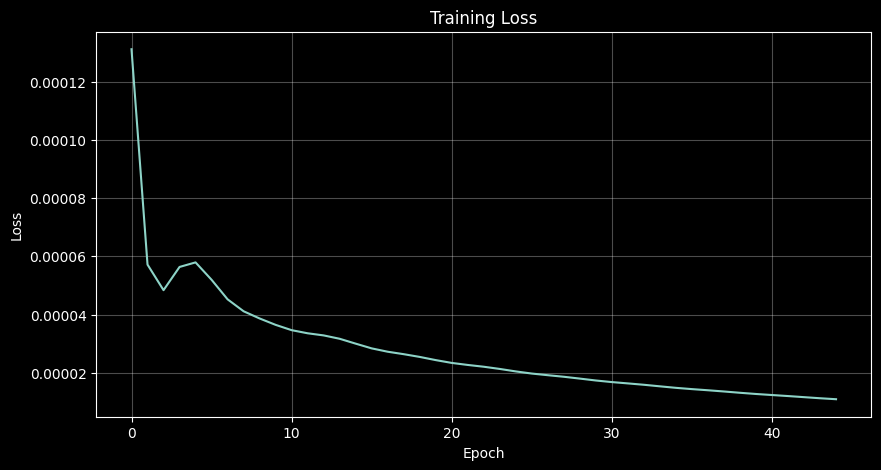

Predicted Lisa tokens: [306, 763, 8709, 292]
Actual Lisa tokens: [306, 763, 8709, 292]
Original text: 'I like sleeping'
Predicted text: 'I like sleeping'


In [56]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

with torch.no_grad():
    predicted_L = model(S_tensor)
    
    # Get the most likely token for each position
    _, predicted_tokens = torch.max(predicted_L, dim=0)
    
    print("Predicted Lisa tokens:", predicted_tokens.tolist())
    print("Actual Lisa tokens:", lisa_tokens)
    
    # Decode the predicted tokens
    predicted_text = lisa_decode(predicted_tokens.tolist())
    print(f"Original text: '{text}'")
    print(f"Predicted text: '{predicted_text}'")

##### pseudoinverse

In [16]:
import numpy as np
import torch
from numpy.linalg import pinv
import matplotlib.pyplot as plt

def create_one_hot_matrix(tokens, vocab_size):
    matrix = np.zeros((vocab_size, len(tokens)))
    for i, token in enumerate(tokens):
        matrix[token, i] = 1
    return matrix

text = 'I like sleeping'
all_sonar_tokens = []
all_lisa_tokens = []

sonar_tokens = sonar_tokenize(text)
lisa_tokens = lisa_tokenize(text)

print('All sonar tokens:', sonar_tokens)
print('All lisa tokens:', lisa_tokens)

# Create one-hot matrices
S = create_one_hot_matrix(sonar_tokens, sonar_vocsize)
L = create_one_hot_matrix(lisa_tokens, lisa_vocsize)

print(f"S shape: {S.shape}")
print(f"L shape: {L.shape}")

# Calculate the pseudoinverse of S
S_pinv = pinv(S)

# Calculate W using the pseudoinverse
W = L @ S_pinv

print(f"W shape: {W.shape}")

# Test the mapping
predicted_L = W @ S
predicted_tokens = predicted_L.argmax(axis=0)

print("Predicted Lisa tokens:", predicted_tokens.tolist())
print("Actual Lisa tokens:", lisa_tokens)


All sonar tokens: [117, 6399, 63295, 87]
All lisa tokens: [306, 763, 8709, 292]
S shape: (256206, 4)
L shape: (32000, 4)
W shape: (32000, 256206)
Predicted Lisa tokens: [306, 763, 8709, 292]
Actual Lisa tokens: [306, 763, 8709, 292]


S: _I _li ke _sleep ing
L: _I _like  _sleep ing

S: _I _like (x) _sleep ing
L: _I _li   ke  _sleep ing


P(_li) = P(_like) + P(_lime) + P(_lip)


S:     _I _like   _sleep ing
S + L: _I _li ke _sleep ing

P_s(_I) -> P_l(_I)
1) P_s(_like) -> P_l(_li) 
2) one_hot_l(ke)

P_s(_icture)
_icture = _ic + tur + re

P_l(_picture) 


P_s(_li) = P_l(_like) + P_l(_lime) + P_l(_lip)




In [ ]:
1) улучшить мета-токенизацию?

In [ ]:
def get_token_mapping(text):
    mapping = {}
    i = 0
    for word in text.split():
        sonar_tokens = sonar_tokenize(word)
        lisa_tokens = lisa_tokenize(word)
        
        if len(sonar_tokens) == len(lisa_tokens):
            for s, l in zip(sonar_tokens, lisa_tokens):
                mapping[s] = l

        elif len(sonar_tokens) < len(lisa_tokens):
            for s, l in zip(sonar_tokens, lisa_tokens[:len(sonar_tokens)]):
                mapping[s] = l
        
        else:
            for i in range(len(sonar_tokens)):
                if sonar_decode([sonar_tokens[i]]) == lisa_decode([lisa_tokens[i]]).replace('▁', ''):
                    lisa_new_tokens.append(lisa_tokens[i])
                else:
                    missed_positions.append(i)
    return mapping

In [26]:
delete_positions = []
one_hot_positions = []
lisa_new_tokens = []

i = 0
for word in text.split():
    sonar_tokens = sonar_tokenize(word)
    lisa_tokens = lisa_tokenize(word)
    
    if len(sonar_tokens) == len(lisa_tokens):
        lisa_new_tokens.extend(lisa_tokens)
        i += len(sonar_tokens)

    elif len(sonar_tokens) < len(lisa_tokens):
        lisa_new_tokens.extend(lisa_tokens[:len(sonar_tokens)])
    
    else:
        for i in range(len(sonar_tokens)):
            if sonar_decode([sonar_tokens[i]]) == lisa_decode([lisa_tokens[i]]).replace('▁', ''):
                lisa_new_tokens.append(lisa_tokens[i])
            else:
                missed_positions.append(i)

print(lisa_new_tokens)
print(missed_positions)


[306, 763, 8709, 292]
[]


In [20]:
lisa_tokens = lisa_tokenize(text)
lisa_tokens

[306, 763, 8709, 292]

In [22]:
lisa_decode(lisa_tokens)

'I like sleeping'